In [1]:
import numpy as np
import matplotlib.pyplot as plt
import Parameters as Pars
from holodeck import sams, utils, hardening, host_relations, cosmo
from holodeck.constants import MSOL, SPLC, NWTG, MPC, GYR, YR
from Two_Par_Variation import TwoDimParVar
from scipy import stats
from scipy.integrate import quad
from Nanograv_15_year_constraints import interpolate_h_ss_max_Nano_15, get_UL_vs_freq
import h5py
import emcee

In [2]:
with h5py.File('../../data/15yr_quickCW_UL.h5', 'r') as f:
    samples_cold = f['samples_cold'][0,0::1,:]
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
log10_fgws = samples_cold[0::1,3]
log10_hs = samples_cold[0::1,4]

In [3]:
#Generate frequency bins according to simulation
OBS_DUR = 10.0 * YR    # duration of PTA observations in [sec], which determines the Fourier frequency basis
NUM_FREQS = 40  # number of frequency bins
fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
NUM_REALS = 1000  # Number of 'realizations' to generate
NUM_LOUDEST = 4  # Number of 'loudest' binaries to generate in each frequency bin

In [4]:
plt.rcParams.update({'font.size': 12})

In [5]:
f_min = 1e-9
f_max = 3e-7
#h = get_UL_vs_freq(log10_fgws, log10_hs, [f_min,f_max])
Dist_freq, UL_freq, bincenters, xedges = get_UL_vs_freq(log10_fgws, log10_hs, [f_min,f_max], n_bins = 40)

In [6]:
widths = 10**xedges[1:] - 10**xedges[:-1]
#Convert GW strain to characteristic strain
Dist_freq = np.sqrt(np.power(10,bincenters)/widths)*Dist_freq
UL_freq = np.sqrt(np.power(10,bincenters)/widths)*UL_freq

In [7]:
minh = 0 #Finds the smallest strain for each frequency bin
maxh = np.array([np.max(v) for v in Dist_freq]) #Finds the largest strain for each frequency bin
h_range = np.transpose(np.linspace(minh,maxh,200)) #Gives a range of values of h over which to apply the kde, for each frequency bin

In [8]:
kde = [stats.gaussian_kde(v) for v in Dist_freq] 

In [9]:
Unif = 1/(maxh - minh)

In [10]:
par1 = Pars.psi0
par2 = Pars.m0
#parname1 = tauname
#parname2 = gamma_innername
ranges = dict([par1, par2])

In [11]:
t1 = TwoDimParVar(ranges,bound_type='hc',shape=30,full_analysis=False)

In [12]:
pdf = t1.get_Strain_pdf()

In [15]:
hc = t1.flattenPars()[0]

In [17]:
hc = t1.flattenPars()[0]
hc = [hc[0,7,i,:,0].ravel() for i,v in enumerate(t1.getFreqs()[0])]
minf0 = [np.min(v) for v in hc]
maxf0 = [np.max(v) for v in hc]

<Figure size 640x480 with 0 Axes>

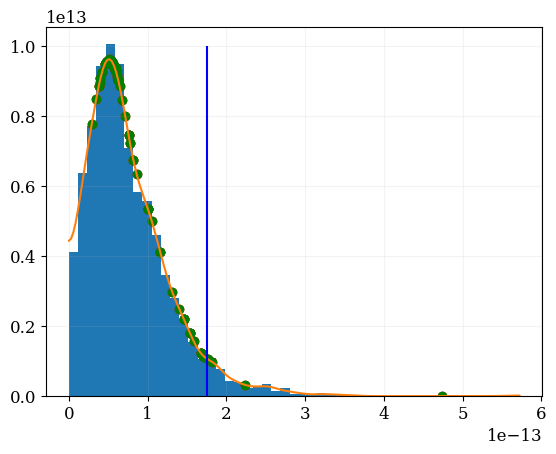

<Figure size 640x480 with 0 Axes>

In [19]:
plt.hist(Dist_freq[0],bins=np.linspace(min(Dist_freq[0]),max(Dist_freq[0])),density=True)
plt.scatter(hc[0], kde[0](hc[0]) + kde[0](-hc[0]), color = 'red')
#plt.scatter(hc[0], pdf[0,7,0,:,0].ravel(), color = 'green')
plt.plot(h_range[0],kde[0](h_range[0]) + kde[0](-h_range[0]))
#plt.hlines(Unif[0], minh, maxh[0],color='red')
plt.vlines(UL_freq[0], 0, 10**13, color= 'blue')
#plt.xscale('log')
#plt.savefig('Green-Circle.png')
plt.figure()

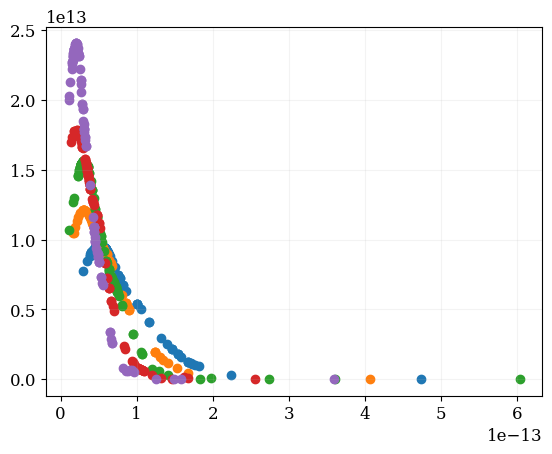

In [27]:
for i,v in enumerate(h_range[0:5]):
    #plt.hist(Dist_freq[i],bins=np.linspace(min(Dist_freq[i]),max(Dist_freq[i])),density=True)
    #plt.plot(v,kde[i](v) + kde[i](-v))
    plt.scatter(hc[i], kde[i](hc[i]) + kde[i](-hc[i]))
    #plt.scatter(hc[i], pdf[0,7,i,:,0].ravel(), color = 'green')
    #plt.hlines(Unif[i],0,maxh[i],color='red')
    #plt.vlines(UL_freq[i], 0, 10**13, color= 'blue')
    #plt.title(f'Frequency $10^{bincenters[i]}$')
    #plt.yscale('log')
    #plt.setylim(0,1e13)